<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Paired_t_test_errors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Case Study:
A software company conducted a training program to reduce coding errors by the programming team. The manager wishes to check the accuracy and effectiveness of the training program in reducing the errors. Errors made before and after training is collected in the data.
Data file: error.xlsx

In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read data
df1 = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/error.xlsx')

# Exploratory Analysis

In [5]:
df1.columns

Index(['Programmer', 'errors_before', 'errors_after'], dtype='object')

In [4]:
df1.head()                                  # Viewing first few observations of the data

,Programmer,errors_before,errors_after
0,1,17,11
1,2,21,12
2,3,23,20
3,4,16,15
4,5,15,14


In [6]:
df1.describe()                              # Descriptive statistics

,Programmer,errors_before,errors_after
count,10.00000,10.000000,10.000000
mean,5.50000,18.900000,16.500000
std,3.02765,3.314949,3.807887
min,1.00000,15.000000,11.000000
25%,3.25000,16.250000,14.250000
50%,5.50000,18.000000,16.000000
75%,7.75000,20.750000,19.500000
max,10.00000,25.000000,23.000000


In [7]:
# Taking difference
df1['errors_diff'] = df1['errors_after'] - df1['errors_before']
df1['errors_diff'].describe()

,errors_diff
count,10.000000
mean,-2.400000
std,2.988868
min,-9.000000
25%,-2.750000
50%,-1.500000
75%,-1.000000
max,1.000000


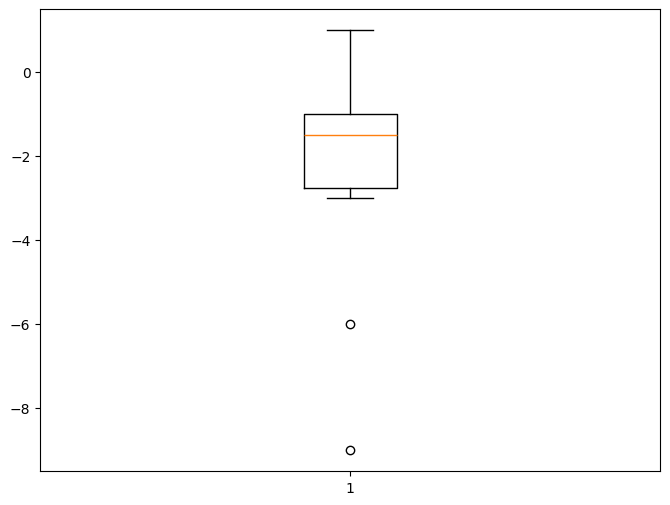

In [8]:
# Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(df1['errors_diff'])
plt.show()

In [9]:
# Checking Normality using Shapiro test
Shapiro1=stats.shapiro(df1['errors_diff'])
Shapiro1

ShapiroResult(statistic=np.float64(0.8573662784138593), pvalue=np.float64(0.07103542256581372))

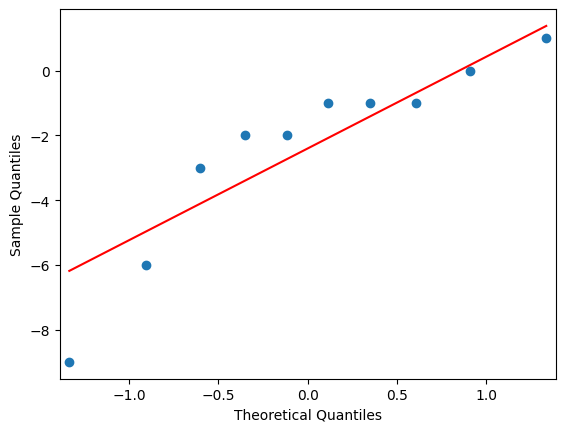

In [10]:
# Checking Normality using Q-Q plot
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

qqplot(df1['errors_diff'],line='s')
plt.show()

In [11]:
# Paired t test / t test for dependent samples

ttest=stats.ttest_rel(df1['errors_after'] , df1['errors_before'], alternative ='less')
ttest

TtestResult(statistic=np.float64(-2.5392442170909537), pvalue=np.float64(0.015875064601223933), df=np.int64(9))

In [12]:
print("Average errors before training:", df1['errors_before'].mean())
print("Average errors after training :", df1['errors_after'].mean())

Average errors before training: 18.9
Average errors after training : 16.5
